<a href="https://colab.research.google.com/github/Muhammad-Musharraf/Loan-Approved-Prediction-ML-Project/blob/main/Data/Loan_Approved_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 💰 **Loan Approved Prediction using Machine Learning**

# **Author**
# Muhammad Musharraf

# **Objective**
### The objective of this project is to predict whether a loan application will be approved based on applicant information such as income, education, employment status, credit history, and loan amount.

# **Technologies Used**
* Python
* Pandas
* NumPy
* Matplotlib
* Seaborn
* Scikit-learn


# **1. Introduction**
### Loan approval prediction is a classification problem where the goal is to determine whether a loan application should be approved or rejected based on applicant characteristics.This project aims to build machine learning Projects

# **2. Import Libraries**
### Import all required libraries for data analysis, visualization, preprocessing.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns


In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# **3. Load Dataset**
### **Load the Dataset**
### Display:
  * Dataset shape
  * First five rows
  * Data types
  * Rename Columns
# **Observation**
Brief overview of the dataset and target variable.


In [3]:
df=pd.read_csv("/content/drive/MyDrive/loan_data.csv")

In [10]:
df.head()

,person_age,person_gender,person_education,person_income,person_emp_exp,person_home_ownership,loan_amnt,loan_intent,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,previous_loan_defaults_on_file,loan_status
0,22.0,female,Master,71948.0,0,RENT,35000.0,PERSONAL,16.02,0.49,3.0,561,No,1
1,21.0,female,High School,12282.0,0,OWN,1000.0,EDUCATION,11.14,0.08,2.0,504,Yes,0
2,25.0,female,High School,12438.0,3,MORTGAGE,5500.0,MEDICAL,12.87,0.44,3.0,635,No,1
3,23.0,female,Bachelor,79753.0,0,RENT,35000.0,MEDICAL,15.23,0.44,2.0,675,No,1
4,24.0,male,Master,66135.0,1,RENT,35000.0,MEDICAL,14.27,0.53,4.0,586,No,1


In [6]:
df.shape

(45000, 14)

In [5]:
df.dtypes

,0
person_age,float64
person_gender,object
person_education,object
person_income,float64
person_emp_exp,int64
person_home_ownership,object
loan_amnt,float64
loan_intent,object
loan_int_rate,float64
loan_percent_income,float64


In [ ]:
df.rename(columns={"loan_amnt":"Loan Amount",	"loan_intent":"Loan Intent","loan_int_rate":"Loan interest Rate","loan_percent_income":"Loan percentage","cb_person_cred_hist_length":"Credit History",	"credit_score":"Credit Score",
                   "previous_loan_defaults_on_file":"Previous Loan",	"loan_status":"Loan Status","person_age":"Age","person_gender":"Gender","person_education":"Education","person_income":"Person Income","person_emp_exp":"Employee Experience","person_home_ownership":"Home Onwership",
                   "Loan Intent_EDUCATION":"Education Loan","Loan Intent_HOMEIMPROVEMENT":"Home Improvement Loan","Loan Intent_MEDICAL":"Medical Loan","Loan Intent_PERSONAL":"Personal Loan","Loan Intent_VENTURE":"Venture Loan"},inplace=True)

# **4. Data Understanding & Data Cleaning**

## **Overview**

The dataset was examined to understand its structure, data types, summary statistics, and missing values. Numerical and categorical features were identified for further preprocessing.

## **Data Cleaning**

The following preprocessing steps were performed:

* Checked dataset shape and feature information.
* Analyzed summary statistics and missing values.
* Imputed missing values using appropriate techniques:

  * **LoanAmount** → Median
  * **Credit_History** → Mode
  * **Self_Employed** → Mode
* Checked and removed duplicate records (if any).
* Verified data quality before model training.

## **Observation**

* The dataset contained both numerical and categorical features.
* Missing values were successfully handled using median and mode imputation.
* No significant data quality issues remained after preprocessing.
* The cleaned dataset was ready for exploratory analysis and model development.


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45000 entries, 0 to 44999
Data columns (total 14 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   person_age                      45000 non-null  float64
 1   person_gender                   45000 non-null  object 
 2   person_education                45000 non-null  object 
 3   person_income                   45000 non-null  float64
 4   person_emp_exp                  45000 non-null  int64  
 5   person_home_ownership           45000 non-null  object 
 6   loan_amnt                       45000 non-null  float64
 7   loan_intent                     45000 non-null  object 
 8   loan_int_rate                   45000 non-null  float64
 9   loan_percent_income             45000 non-null  float64
 10  cb_person_cred_hist_length      45000 non-null  float64
 11  credit_score                    45000 non-null  int64  
 12  previous_loan_defaults_on_file  

In [ ]:
df["Age"].unique()

array([ 22.,  21.,  25.,  23.,  24.,  26., 144., 123.,  20.,  32.,  34.,
        29.,  33.,  28.,  35.,  31.,  27.,  30.,  36.,  40.,  50.,  45.,
        37.,  39.,  44.,  43.,  41.,  46.,  38.,  47.,  42.,  48.,  49.,
        58.,  65.,  51.,  53.,  66.,  61.,  54.,  57.,  59.,  62.,  60.,
        55.,  52.,  64.,  70.,  78.,  69.,  56.,  73.,  63.,  94.,  80.,
        84.,  76.,  67., 116., 109.])

In [ ]:
df['Age']=df['Age'].astype("int64")

In [ ]:
df["Age"].head()

,Age
0,22
1,21
2,25
3,23
4,24


In [ ]:
df["Loan Amount"].unique()

array([35000.,  1000.,  5500., ..., 12229.,  2771.,  6665.])

In [ ]:
df['Loan Amount']=df['Loan Amount'].astype("int64")

In [ ]:
df["Loan Amount"].head()

,Loan Amount
0,35000
1,1000
2,5500
3,35000
4,35000


In [ ]:
df['Person Income'].unique()

array([71948., 12282., 12438., ..., 31924., 56942., 33164.])

In [ ]:
df['Person Income']=df['Person Income'].astype("int64")

In [ ]:
df['Person Income'].head()

,Person Income
0,71948
1,12282
2,12438
3,79753
4,66135


In [ ]:
df['Credit Score'].unique()

array([561, 504, 635, 675, 586, 532, 701, 585, 544, 640, 621, 651, 573,
       708, 583, 670, 663, 694, 709, 679, 684, 662, 691, 600, 654, 626,
       607, 700, 553, 589, 681, 567, 669, 606, 582, 649, 602, 616, 631,
       637, 695, 620, 622, 645, 624, 570, 648, 652, 559, 623, 609, 579,
       688, 661, 562, 664, 564, 598, 557, 677, 690, 599, 604, 601, 634,
       671, 789, 538, 587, 683, 518, 617, 668, 673, 706, 536, 689, 595,
       584, 642, 614, 597, 625, 603, 643, 508, 505, 593, 686, 646, 697,
       615, 687, 650, 588, 658, 531, 665, 703, 594, 618, 574, 577, 653,
       630, 660, 639, 612, 628, 592, 580, 678, 672, 613, 566, 718, 484,
       699, 656, 659, 636, 554, 807, 578, 674, 608, 569, 629, 560, 548,
       667, 676, 581, 655, 551, 529, 666, 576, 633, 611, 657, 647, 542,
       692, 545, 540, 525, 537, 641, 539, 563, 712, 491, 590, 572, 528,
       638, 627, 596, 547, 507, 565, 693, 522, 632, 556, 499, 704, 503,
       714, 552, 555, 558, 521, 605, 571, 591, 719, 610, 535, 64

In [ ]:
df['Credit History']=df['Credit History'].astype(int)

In [ ]:
df['Credit History'].dtypes

dtype('int64')

### Check Duplicate

In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df.describe()

,Age,Person Income,Employee Experience,Loan Amount,Loan interest Rate,Loan percentage,Credit History,Credit Score,Loan Status
count,45000.000000,4.500000e+04,45000.000000,45000.000000,45000.000000,45000.000000,45000.000000,45000.000000,45000.000000
mean,27.764178,8.031905e+04,5.410333,9583.157556,11.006606,0.139725,5.867489,632.608756,0.222222
std,6.045108,8.042250e+04,6.063532,6314.886691,2.978808,0.087212,3.879702,50.435865,0.415744
min,20.000000,8.000000e+03,0.000000,500.000000,5.420000,0.000000,2.000000,390.000000,0.000000
25%,24.000000,4.720400e+04,1.000000,5000.000000,8.590000,0.070000,3.000000,601.000000,0.000000
50%,26.000000,6.704800e+04,4.000000,8000.000000,11.010000,0.120000,4.000000,640.000000,0.000000
75%,30.000000,9.578925e+04,8.000000,12237.250000,12.990000,0.190000,8.000000,670.000000,0.000000
max,144.000000,7.200766e+06,125.000000,35000.000000,20.000000,0.660000,30.000000,850.000000,1.000000


In [ ]:
df.columns

Index(['Age', 'Gender', 'Education', 'Person Income', 'Employee Experience',
       'Home Onwership', 'Loan Amount', 'Loan Intent', 'Loan interest Rate',
       'Loan percentage', 'Credit History', 'Credit Score', 'Previous Loan',
       'Loan Status'],
      dtype='object')

### Check NULL Values

In [ ]:
df.isnull().sum()

,0
Age,0
Gender,0
Education,0
Person Income,0
Employee Experience,0
Home Onwership,0
Loan Amount,0
Loan Intent,0
Loan interest Rate,0
Loan percentage,0


## Save the Clean Loan Data in CSV Format

In [ ]:
df.to_csv("loan_data_new.csv",index=False)

## Check Unique Values of All Columns.

In [ ]:
df['Credit History'].unique()

array([ 3,  2,  4,  8,  7,  6,  9, 10,  5, 11, 16, 15, 12, 13, 17, 14, 25,
       28, 27, 22, 19, 29, 23, 26, 20, 21, 30, 24, 18])

In [ ]:
df['Credit Score'].unique()

array([561, 504, 635, 675, 586, 532, 701, 585, 544, 640, 621, 651, 573,
       708, 583, 670, 663, 694, 709, 679, 684, 662, 691, 600, 654, 626,
       607, 700, 553, 589, 681, 567, 669, 606, 582, 649, 602, 616, 631,
       637, 695, 620, 622, 645, 624, 570, 648, 652, 559, 623, 609, 579,
       688, 661, 562, 664, 564, 598, 557, 677, 690, 599, 604, 601, 634,
       671, 789, 538, 587, 683, 518, 617, 668, 673, 706, 536, 689, 595,
       584, 642, 614, 597, 625, 603, 643, 508, 505, 593, 686, 646, 697,
       615, 687, 650, 588, 658, 531, 665, 703, 594, 618, 574, 577, 653,
       630, 660, 639, 612, 628, 592, 580, 678, 672, 613, 566, 718, 484,
       699, 656, 659, 636, 554, 807, 578, 674, 608, 569, 629, 560, 548,
       667, 676, 581, 655, 551, 529, 666, 576, 633, 611, 657, 647, 542,
       692, 545, 540, 525, 537, 641, 539, 563, 712, 491, 590, 572, 528,
       638, 627, 596, 547, 507, 565, 693, 522, 632, 556, 499, 704, 503,
       714, 552, 555, 558, 521, 605, 571, 591, 719, 610, 535, 64

In [ ]:
df['Loan Intent'].value_counts()

,count
Loan Intent,
EDUCATION,9153
MEDICAL,8548
VENTURE,7819
PERSONAL,7552
DEBTCONSOLIDATION,7145
HOMEIMPROVEMENT,4783


In [ ]:
df['Loan Amount'].unique()

array([35000,  1000,  5500, ..., 12229,  2771,  6665])

In [ ]:
df['Loan Status'].value_counts()

,count
Loan Status,
0,35000
1,10000


In [ ]:
df['Loan percentage'].unique()

array([0.49, 0.08, 0.44, 0.53, 0.19, 0.37, 0.35, 0.13, 0.34, 0.3 , 0.27,
       0.25, 0.05, 0.24, 0.31, 0.26, 0.12, 0.18, 0.21, 0.43, 0.11, 0.4 ,
       0.32, 0.1 , 0.41, 0.22, 0.07, 0.02, 0.17, 0.51, 0.38, 0.33, 0.06,
       0.03, 0.28, 0.04, 0.09, 0.2 , 0.23, 0.15, 0.48, 0.5 , 0.14, 0.42,
       0.01, 0.46, 0.29, 0.39, 0.36, 0.16, 0.  , 0.57, 0.45, 0.52, 0.55,
       0.61, 0.62, 0.66, 0.54, 0.47, 0.56, 0.58, 0.63, 0.59])

In [ ]:
df['Previous Loan'].value_counts()

,count
Previous Loan,
Yes,22858
No,22142


In [ ]:
df['Loan interest Rate'].unique()

array([16.02, 11.14, 12.87, ..., 19.11, 19.8 , 16.92])

In [ ]:
df['Home Onwership'].value_counts()

,count
Home Onwership,
RENT,23443
MORTGAGE,18489
OWN,2951
OTHER,117


In [ ]:
df['Education'].value_counts()

,count
Education,
Bachelor,13399
Associate,12028
High School,11972
Master,6980
Doctorate,621


In [ ]:
df['Age'].unique()

array([ 22,  21,  25,  23,  24,  26, 144, 123,  20,  32,  34,  29,  33,
        28,  35,  31,  27,  30,  36,  40,  50,  45,  37,  39,  44,  43,
        41,  46,  38,  47,  42,  48,  49,  58,  65,  51,  53,  66,  61,
        54,  57,  59,  62,  60,  55,  52,  64,  70,  78,  69,  56,  73,
        63,  94,  80,  84,  76,  67, 116, 109])

# **5. Exploratory Data Analysis (EDA)**

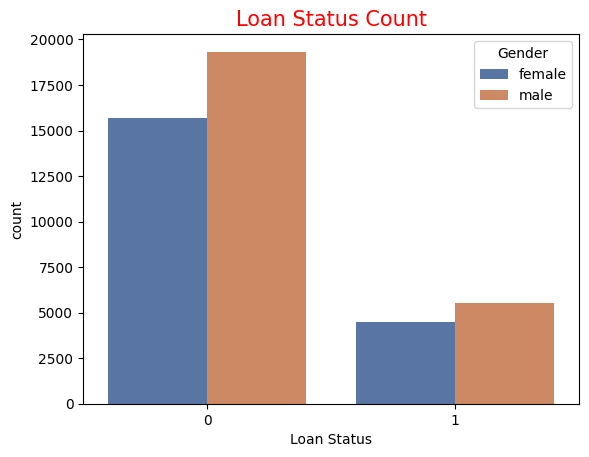

In [ ]:
sns.countplot(data=df,x='Loan Status',hue="Gender",palette="deep")
plt.title("Loan Status Count",color='red',fontsize=15)
plt.show()

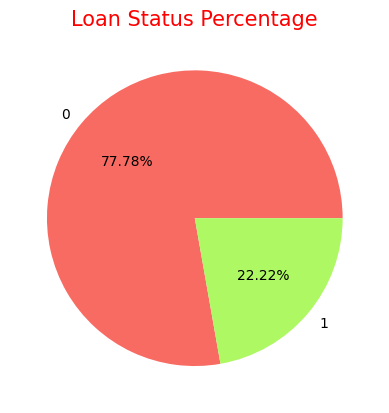

In [ ]:
plt.pie(df['Loan Status'].value_counts(),labels=df['Loan Status'].value_counts().index,autopct='%1.2f%%',colors=["#F86B63","#ADF863"])
plt.title("Loan Status Percentage",color='red',fontsize=15)
plt.show()

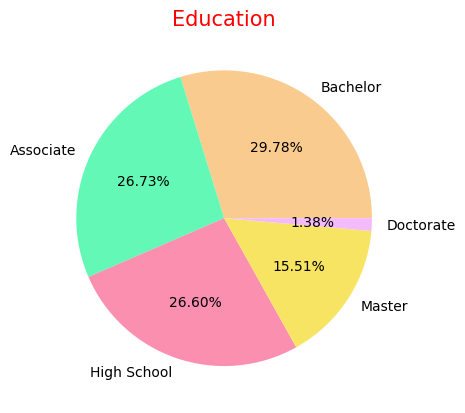

In [ ]:
plt.pie(df['Education'].value_counts(),labels=df['Education'].value_counts().index,autopct='%1.2f%%',colors=["#FACB8F","#63F8B5","#FA8FAF","#F8E463","#F4BBFC"])
plt.title("Education",color='red',fontsize=15)
plt.show()

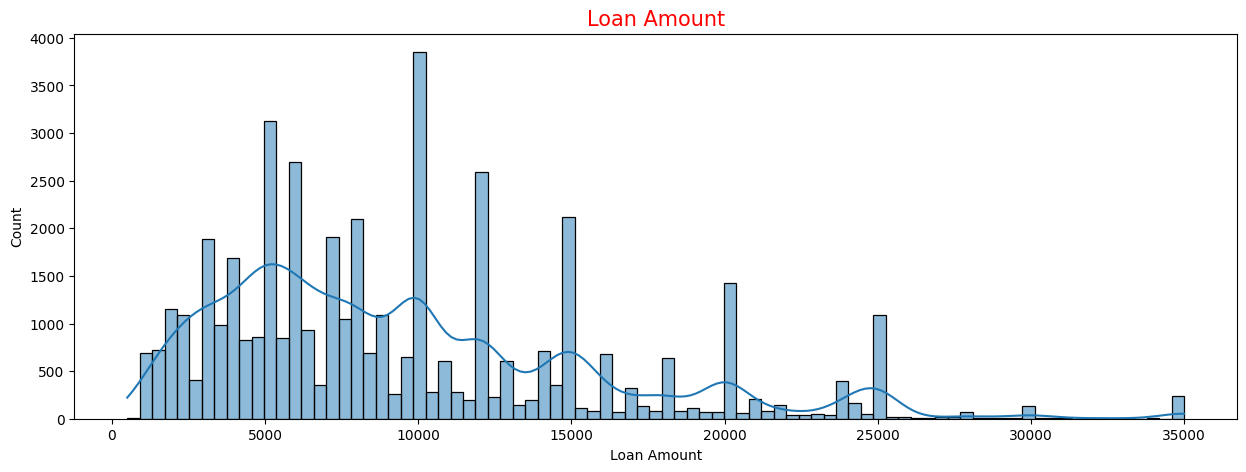

In [ ]:
plt.figure(figsize=(15,5))

sns.histplot(data=df,x='Loan Amount',kde=True)
plt.title("Loan Amount",color='red',fontsize=15)
plt.show()

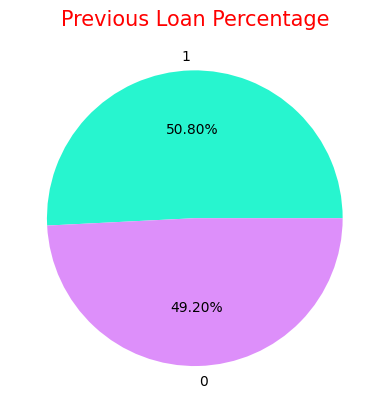

In [ ]:
plt.pie(df['Previous Loan'].value_counts(),labels=df['Previous Loan'].value_counts().index,autopct='%1.2f%%',colors=["#27F5CF","#DD8FFA"])
plt.title("Previous Loan Percentage",color='red',fontsize=15)
plt.show()

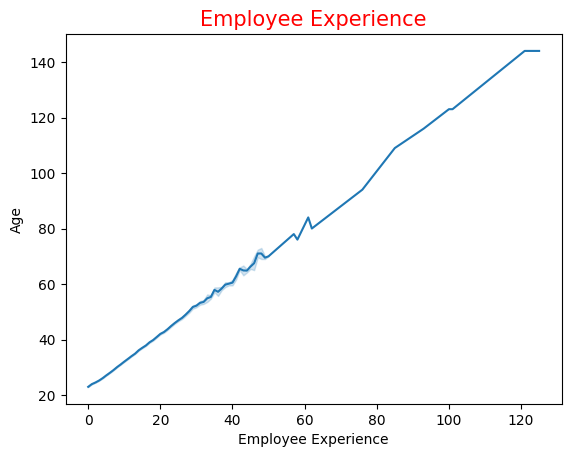

In [ ]:
sns.lineplot(data=df,x="Employee Experience",y="Age")
plt.title("Employee Experience",color='red',fontsize=15)
plt.show()

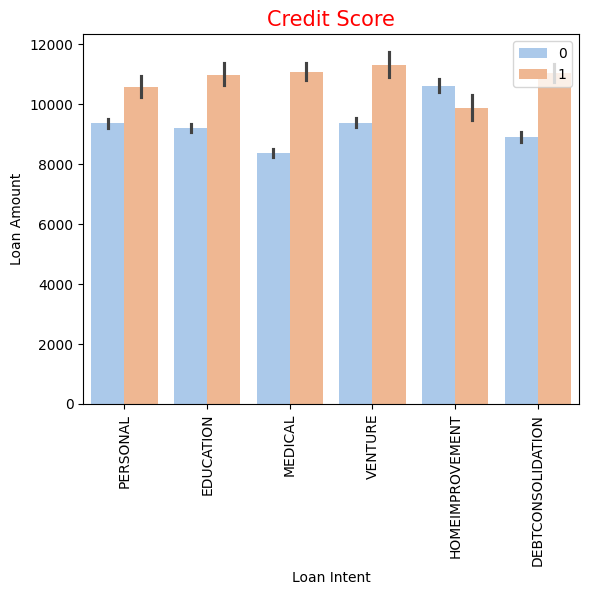

In [ ]:
sns.barplot(data=df,x="Loan Intent",y="Loan Amount",hue="Loan Status",palette="pastel")
plt.title("Credit Score",color='red',fontsize=15)
plt.xticks(rotation=90)
plt.legend(loc='upper right')
plt.show()

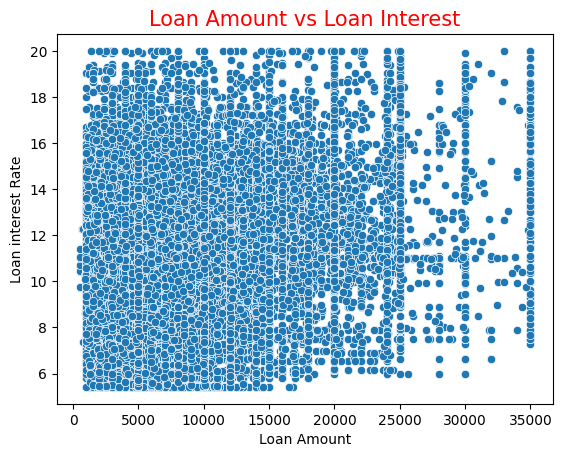

In [ ]:
sns.scatterplot(data=df,x="Loan Amount",y="Loan interest Rate")
plt.title("Loan Amount vs Loan Interest",color='red',fontsize=15)
plt.show()

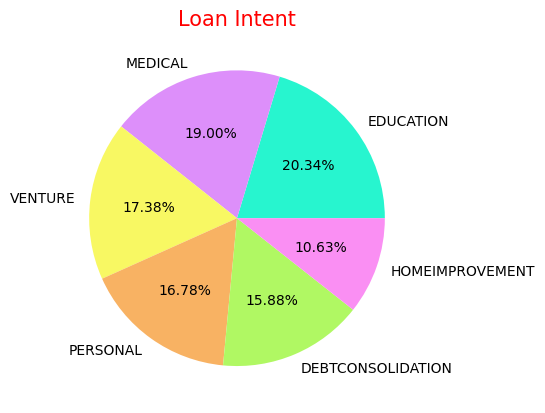

In [ ]:
plt.pie(df['Loan Intent'].value_counts(),labels=df['Loan Intent'].value_counts().index,autopct='%1.2f%%',colors=["#27F5CF","#DD8FFA","#F8F863","#F8B263","#B0F863","#FA8FF3"])
plt.title("Loan Intent",color='red',fontsize=15)
plt.show()

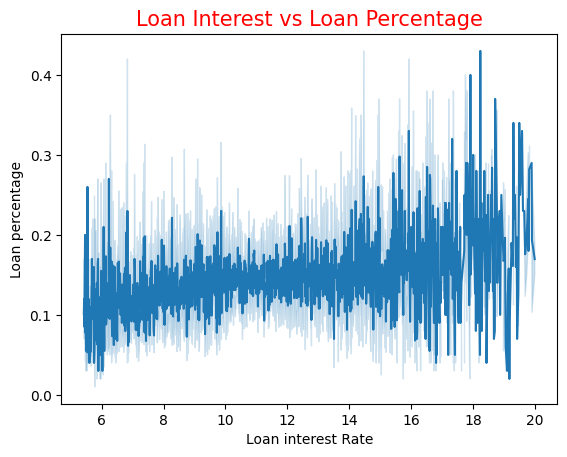

In [ ]:
sns.kdeplot(data=df,x="Loan interest Rate",y="Loan percentage")
plt.title("Loan Interest vs Loan Percentage",color='red',fontsize=15)
plt.show()

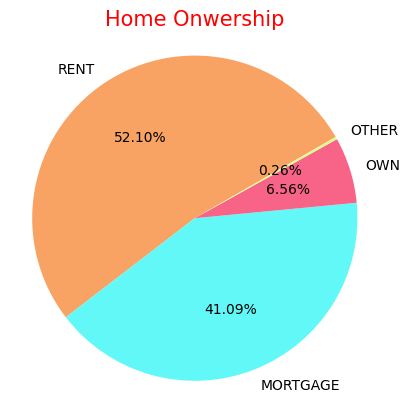

In [ ]:
plt.pie(df['Home Onwership'].value_counts(),labels=df['Home Onwership'].value_counts().index,autopct='%0.2f%%',colors=["#F8A363","#63F8F8","#F86388","#DDFA8F"],radius=1.1,startangle=30)
plt.title("Home Onwership",color='red',fontsize=15)
plt.show()

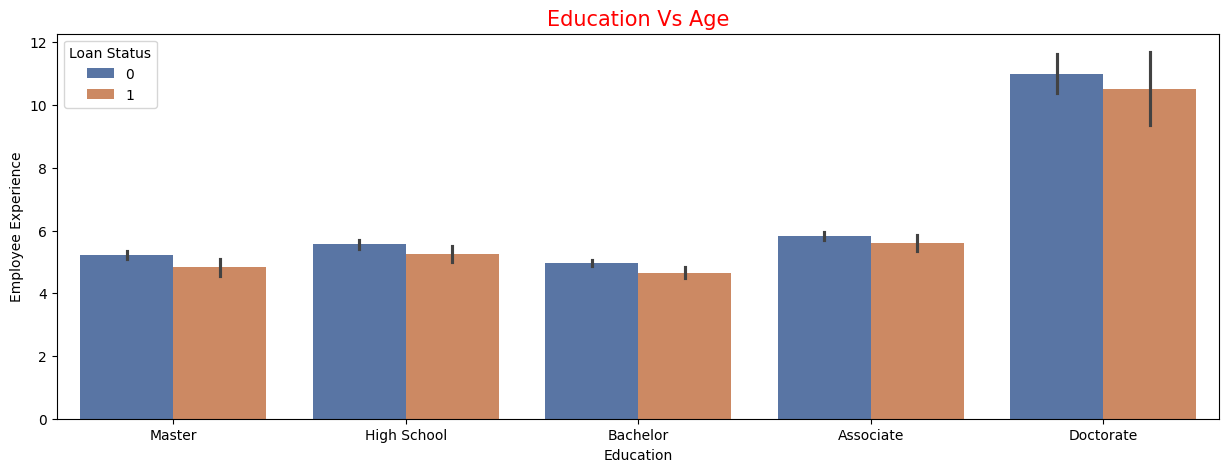

In [ ]:
plt.figure(figsize=(15,5))

sns.barplot(data=df,y="Employee Experience",x="Education",hue="Loan Status",palette="deep")
plt.title("Education Vs Age",color='red',fontsize=15)
plt.show()

In [11]:
df.corr(numeric_only=True)

,person_age,person_income,person_emp_exp,loan_amnt,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,loan_status
person_age,1.000000,0.193698,0.954412,0.050750,0.013402,-0.043299,0.861985,0.178432,-0.021476
person_income,0.193698,1.000000,0.185987,0.242290,0.001510,-0.234177,0.124316,0.035919,-0.135808
person_emp_exp,0.954412,0.185987,1.000000,0.044589,0.016631,-0.039862,0.824272,0.186196,-0.020481
loan_amnt,0.050750,0.242290,0.044589,1.000000,0.146093,0.593011,0.042969,0.009074,0.107714
loan_int_rate,0.013402,0.001510,0.016631,0.146093,1.000000,0.125209,0.018008,0.011498,0.332005
loan_percent_income,-0.043299,-0.234177,-0.039862,0.593011,0.125209,1.000000,-0.031868,-0.011483,0.384880
cb_person_cred_hist_length,0.861985,0.124316,0.824272,0.042969,0.018008,-0.031868,1.000000,0.155204,-0.014851
credit_score,0.178432,0.035919,0.186196,0.009074,0.011498,-0.011483,0.155204,1.000000,-0.007647
loan_status,-0.021476,-0.135808,-0.020481,0.107714,0.332005,0.384880,-0.014851,-0.007647,1.000000


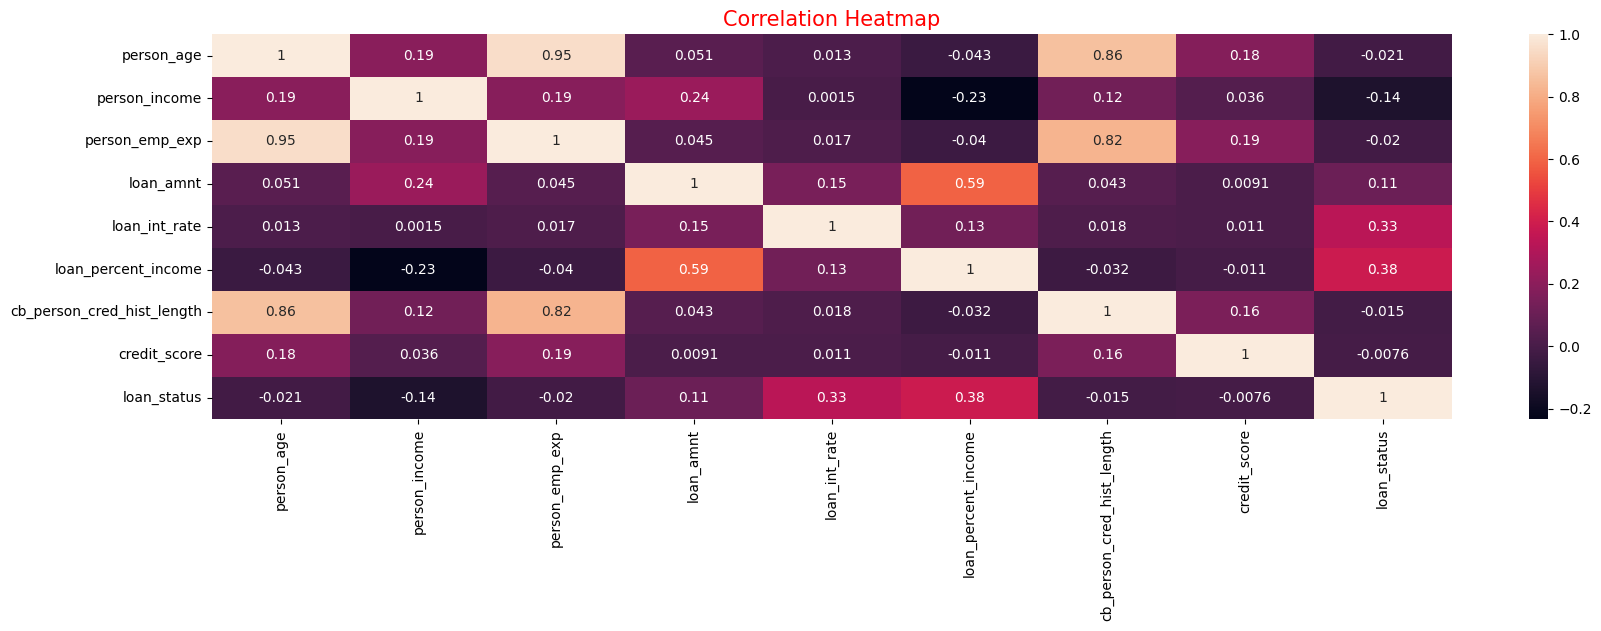

In [13]:
plt.figure(figsize=(20,5))
sns.heatmap(df.corr(numeric_only=True),annot=True)
plt.title("Correlation Heatmap",color='red',fontsize=15)
plt.show()

# **6. Feature Engineering**
## **Encoding Categorical Variables**
###Apply:
  * Label Encoding
  * Ordinal Encoding
  * One-Hot Encoding
  * StandardScalar for Scaling
## **Observation**
Explain transformations.



## Data Encoding & Sacling

In [ ]:
x=df.drop('Loan Status',axis=1)
y=df['Loan Status']

In [ ]:
from sklearn.preprocessing import OneHotEncoder,OrdinalEncoder,LabelEncoder,StandardScaler,MinMaxScaler

In [ ]:
ohe=OneHotEncoder()
le=LabelEncoder()

In [ ]:
ohe.fit(x[['Gender','Home Onwership',"Loan Intent"]])

OneHotEncoder()

In [ ]:
oe=OrdinalEncoder(categories=[['High School','Associate','Bachelor','Master','Doctorate']])
oe.fit(x[['Education']])

OrdinalEncoder(categories=[['High School', 'Associate', 'Bachelor', 'Master',
                            'Doctorate']])

In [ ]:
df['Education'].unique()

array(['Master', 'High School', 'Bachelor', 'Associate', 'Doctorate'],
      dtype=object)

In [ ]:
df['Previous Loan']=le.transform(df['Previous Loan'])

In [ ]:
df.sample(5)

,Age,Gender,Education,Person Income,Employee Experience,Home Onwership,Loan Amount,Loan Intent,Loan interest Rate,Loan percentage,Credit History,Credit Score,Previous Loan,Loan Status
44943,31,male,Bachelor,53738,9,RENT,12000,DEBTCONSOLIDATION,13.30,0.22,7,605,0,1
20711,35,female,Master,43866,11,RENT,5000,MEDICAL,9.91,0.11,5,713,0,0
7594,24,female,Bachelor,60175,1,RENT,6400,MEDICAL,11.01,0.11,3,672,0,1
38115,29,male,Master,31085,4,RENT,5449,PERSONAL,13.07,0.18,6,660,0,0
286,22,male,Associate,106694,0,RENT,25000,DEBTCONSOLIDATION,15.58,0.23,2,667,0,1


In [ ]:
ss=StandardScaler()
ss.fit(x[['Age','Person Income','Employee Experience','Credit Score','Credit History','Loan Amount','Loan interest Rate','Loan percentage']])

StandardScaler()

# **7. Data Preparation**
## **Train-Test Split**
### Example:
* 80% Training
* 20% Testing

In [ ]:
from sklearn.preprocessing import OneHotEncoder,OrdinalEncoder,LabelEncoder,StandardScaler,MinMaxScaler
from sklearn.model_selection import train_test_split

In [ ]:
x=df.drop('Loan Status',axis=1)
y=df['Loan Status']

In [ ]:
x.shape

(45000, 13)

In [ ]:
y.shape

(45000,)

In [ ]:
y.head()

,Loan Status
0,1
1,0
2,1
3,1
4,1


# Train Test Split

In [ ]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

## Column Transformers

In [ ]:
from sklearn.compose import make_column_transformer

In [ ]:
col_trans=make_column_transformer(
    (OneHotEncoder(drop='first',sparse_output=False),['Gender','Home Onwership',"Loan Intent"]),
    (OrdinalEncoder(categories=[['High School','Associate','Bachelor','Master','Doctorate']]),['Education']),
    (StandardScaler(),['Age','Person Income','Employee Experience','Credit Score','Credit History','Loan Amount','Loan interest Rate','Loan percentage']),
    remainder='passthrough'
)

In [ ]:
x_train_transform=col_trans.fit_transform(x_train)
x_test_transform=col_trans.transform(x_test)

# **8. Model Building**
### **Logistic Regression**
### **Decision Tree Classifier**
### **Random Forest Classifier**
### **KNeighborsClassifier**
### **SVC**

# **Results**
### Display:
  * Accuracy
  * Precision
  * Recall
  * F1-Score



## Import All Machine Learning Classification Model Library

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score,f1_score,precision_score,recall_score,classification_report,confusion_matrix

In [ ]:
from sklearn.pipeline import make_pipeline

## Apply LogisticRegression Model and Pipeline With Test Evaluation

In [ ]:
step1=col_trans=make_column_transformer(
    (OneHotEncoder(drop='first',sparse_output=False),['Gender','Home Onwership',"Loan Intent"]),
    (OrdinalEncoder(categories=[['High School','Associate','Bachelor','Master','Doctorate']]),['Education']),
    (StandardScaler(),['Age','Person Income','Employee Experience','Credit Score','Credit History','Loan Amount','Loan interest Rate','Loan percentage']),
    remainder='passthrough'
)

step2=LogisticRegression()

pipe=make_pipeline(step1,step2)
pipe.fit(x_train,y_train)


y_pred=pipe.predict(x_test)

print('accuracy score',accuracy_score(y_test,y_pred))
print("Error",1-accuracy_score(y_test,y_pred))
print('f1 score',f1_score(y_test,y_pred,average='weighted'))
print('precision score',precision_score(y_test,y_pred,average='weighted'))
print('recall score',recall_score(y_test,y_pred,average='weighted'))
print(classification_report(y_test,y_pred))


accuracy score 0.8936666666666667
Error 0.10633333333333328
f1 score 0.8928996578904371
precision score 0.8923143125918894
recall score 0.8936666666666667
              precision    recall  f1-score   support

           0       0.93      0.94      0.93      6990
           1       0.77      0.74      0.76      2010

    accuracy                           0.89      9000
   macro avg       0.85      0.84      0.84      9000
weighted avg       0.89      0.89      0.89      9000



## Apply DecisionTreeClassifier Model and Pipeline With Test Evaluation

In [ ]:
step1=col_trans=make_column_transformer(
    (OneHotEncoder(drop='first',sparse_output=False),['Gender','Home Onwership',"Loan Intent"]),
    (OrdinalEncoder(categories=[['High School','Associate','Bachelor','Master','Doctorate']]),['Education']),
    (StandardScaler(),['Age','Person Income','Employee Experience','Credit Score','Credit History','Loan Amount','Loan interest Rate','Loan percentage']),
    remainder='passthrough'
)

step2=DecisionTreeClassifier(criterion='entropy',max_depth=11,splitter='best')

pipe=make_pipeline(step1,step2)
pipe.fit(x_train,y_train)


y_pred=pipe.predict(x_test)

print('accuracy score',accuracy_score(y_test,y_pred))
print("Error",1-accuracy_score(y_test,y_pred))
print('f1 score',f1_score(y_test,y_pred,average='weighted'))
print('precision score',precision_score(y_test,y_pred,average='weighted'))
print('recall score',recall_score(y_test,y_pred,average='weighted'))
print(classification_report(y_test,y_pred))


accuracy score 0.9207777777777778
Error 0.0792222222222222
f1 score 0.9183537995630128
precision score 0.9190957700450045
recall score 0.9207777777777778
              precision    recall  f1-score   support

           0       0.93      0.97      0.95      6990
           1       0.88      0.75      0.81      2010

    accuracy                           0.92      9000
   macro avg       0.91      0.86      0.88      9000
weighted avg       0.92      0.92      0.92      9000



## GridSearch CV

In [ ]:
from sklearn.model_selection import GridSearchCV,RandomizedSearchCV

In [ ]:
dt={"criterion":["gini", "entropy","log_loss"],
    "splitter":["best","random"],
    "max_depth":[i for i in range(2,20)]}

In [ ]:
gd=GridSearchCV(DecisionTreeClassifier(),param_grid=dt,cv=5)
gd.fit(x_train_transform,y_train)

GridSearchCV(cv=5, estimator=DecisionTreeClassifier(),
             param_grid={'criterion': ['gini', 'entropy', 'log_loss'],
                         'max_depth': [2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13,
                                       14, 15, 16, 17, 18, 19],
                         'splitter': ['best', 'random']})

In [ ]:
gd.best_params_

{'criterion': 'log_loss', 'max_depth': 11, 'splitter': 'best'}

In [ ]:
gd.score(x_test_transform,y_test)

0.921

In [ ]:
dt=DecisionTreeClassifier(criterion='entropy',max_depth=11,splitter='best')
dt.fit(x_train_transform,y_train)

DecisionTreeClassifier(criterion='entropy', max_depth=11)

In [ ]:
dt.score(x_test_transform,y_test)*100,dt.score(x_train_transform,y_train)*100

(92.10000000000001, 93.27222222222223)

# Apply RandomForestClassifier Model and Pipeline With Test Evaluation

In [ ]:
step1=col_trans=make_column_transformer(
    (OneHotEncoder(drop='first',sparse_output=False),['Gender','Home Onwership',"Loan Intent"]),
    (OrdinalEncoder(categories=[['High School','Associate','Bachelor','Master','Doctorate']]),['Education']),
    (StandardScaler(),['Age','Person Income','Employee Experience','Credit Score','Credit History','Loan Amount','Loan interest Rate','Loan percentage']),
    remainder='passthrough'
)

step2=RandomForestClassifier(criterion='entropy',max_depth=11, n_estimators=200)

pipe=make_pipeline(step1,step2)
pipe.fit(x_train,y_train)


y_pred=pipe.predict(x_test)

print('accuracy score',accuracy_score(y_test,y_pred))
print("Error",1-accuracy_score(y_test,y_pred))
print('f1 score',f1_score(y_test,y_pred,average='weighted'))
print('precision score',precision_score(y_test,y_pred,average='weighted'))
print('recall score',recall_score(y_test,y_pred,average='weighted'))
print(classification_report(y_test,y_pred))


accuracy score 0.9228888888888889
Error 0.07711111111111113
f1 score 0.9198659489642881
precision score 0.921919277092907
recall score 0.9228888888888889
              precision    recall  f1-score   support

           0       0.93      0.98      0.95      6990
           1       0.90      0.73      0.81      2010

    accuracy                           0.92      9000
   macro avg       0.92      0.86      0.88      9000
weighted avg       0.92      0.92      0.92      9000



In [ ]:
rf=RandomForestClassifier(criterion='entropy',max_depth=11, n_estimators=200)
rf.fit(x_train_transform,y_train)

RandomForestClassifier(criterion='entropy', max_depth=11, n_estimators=200)

In [ ]:
rf.score(x_test_transform,y_test)*100,rf.score(x_train_transform,y_train)*100

(92.35555555555555, 93.6388888888889)

In [ ]:
x_train.columns

Index(['Age', 'Gender', 'Education', 'Person Income', 'Employee Experience',
       'Home Onwership', 'Loan Amount', 'Loan Intent', 'Loan interest Rate',
       'Loan percentage', 'Credit History', 'Credit Score', 'Previous Loan'],
      dtype='object')

# **9. Prediction Example**
Predict loan approval for a sample applicant.
## **Display:**
  * Input Features
  * Predicted Class
  * Approval Probability

In [ ]:
pipe.predict(pd.DataFrame(columns=['Age', 'Gender', 'Education', 'Person Income', 'Employee Experience','Home Onwership', 'Loan Amount', 'Loan Intent', 'Loan interest Rate','Loan percentage', 'Credit History', 'Credit Score', 'Previous Loan'],
                          data=np.array([22,"female","Master",71948,0,"RENT",35000,"PERSONAL",16.02,0.49,3,561,0]).reshape(1,13)))

array([1])

## Apply SVC Model and Pipeline With Test Evaluation

In [ ]:
step1=col_trans=make_column_transformer(
    (OneHotEncoder(drop='first',sparse_output=False),['Gender','Home Onwership',"Loan Intent"]),
    (OrdinalEncoder(categories=[['High School','Associate','Bachelor','Master','Doctorate']]),['Education']),
    (StandardScaler(),['Age','Person Income','Employee Experience','Credit Score','Credit History','Loan Amount','Loan interest Rate','Loan percentage']),
    remainder='passthrough'
)

step2=SVC()

pipe=make_pipeline(step1,step2)
pipe.fit(x_train,y_train)


y_pred=pipe.predict(x_test)

print('accuracy score',accuracy_score(y_test,y_pred))
print("Error",1-accuracy_score(y_test,y_pred))
print('f1 score',f1_score(y_test,y_pred,average='weighted'))
print('precision score',precision_score(y_test,y_pred,average='weighted'))
print('recall score',recall_score(y_test,y_pred,average='weighted'))
print(classification_report(y_test,y_pred))


accuracy score 0.9151111111111111
Error 0.0848888888888889
f1 score 0.9132401903485764
precision score 0.9130419928480332
recall score 0.9151111111111111
              precision    recall  f1-score   support

           0       0.93      0.96      0.95      6990
           1       0.85      0.75      0.80      2010

    accuracy                           0.92      9000
   macro avg       0.89      0.86      0.87      9000
weighted avg       0.91      0.92      0.91      9000



## Import Pickle

In [ ]:
import pickle

## Save the Model

In [ ]:
pickle.dump(pipe,open('pipe.pkl','wb'))
pickle.dump(df,open('df.pkl','wb'))

In [ ]:
df.head()

,Age,Gender,Education,Person Income,Employee Experience,Home Onwership,Loan Amount,Loan Intent,Loan interest Rate,Loan percentage,Credit History,Credit Score,Previous Loan,Loan Status
0,22,female,Master,71948,0,RENT,35000,PERSONAL,16.02,0.49,3,561,0,1
1,21,female,High School,12282,0,OWN,1000,EDUCATION,11.14,0.08,2,504,1,0
2,25,female,High School,12438,3,MORTGAGE,5500,MEDICAL,12.87,0.44,3,635,0,1
3,23,female,Bachelor,79753,0,RENT,35000,MEDICAL,15.23,0.44,2,675,0,1
4,24,male,Master,66135,1,RENT,35000,MEDICAL,14.27,0.53,4,586,0,1


# **10. Conclusion**

## **Key Findings**

This project successfully developed a machine learning model to predict loan approval status based on applicant information.

The main findings are:

* Credit History emerged as the most influential feature in determining loan approval.
* Applicants with stable and higher incomes showed a greater likelihood of receiving loan approval.
* Proper data preprocessing and feature engineering improved the model's predictive performance.
* Among the evaluated models, the selected model achieved the highest classification performance and demonstrated good generalization on unseen data.

## **Future Improvements**

The project can be further enhanced through:

* Hyperparameter tuning to optimize model performance.
* Incorporating additional financial and demographic features.
* Applying advanced ensemble learning techniques.
* Deploying the model using Streamlit and FastAPI for real-time predictions.
* Developing a complete real-time loan approval decision support system for financial institutions.

## **Final Remark**

The developed loan approval prediction system demonstrates how machine learning can assist financial organizations in making faster, more consistent, and data-driven lending decisions while reducing manual effort and risk.
